In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_excel("D:/Ruslan/main.xlsx")
print(data.head())
print("Unique conditions (raw):", data['Condition'].unique())

   IMG name  Voltage, V  Current, A Condition
0         1       20.21       2.000     clean
1         2       20.27       2.006     clean
2         3       20.33       2.010     clean
3         4       20.33       2.009     clean
4         5       20.32       2.007     clean
Unique conditions (raw): ['clean' 'water' 'dust' 'snow']


In [4]:
# 2) LABEL ENCODE THE CONDITION COLUMN
#    Mapping -> {'clean': 0, 'dust': 1, 'snow': 2, 'water': 3}

labelencoder = LabelEncoder()
data['Condition'] = labelencoder.fit_transform(data['Condition'])
print("Unique conditions (encoded):", data['Condition'].unique())

Unique conditions (encoded): [0 3 1 2]


In [5]:
# 3) ADD FULL FILE PATHS TO THE DATAFRAME

image_dir = "D:/Ruslan/main/"
data['ImagePath'] = data['IMG name'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)
print(data[['IMG name','Condition','ImagePath']].head())

   IMG name  Condition             ImagePath
0         1          0  D:/Ruslan/main/1.jpg
1         2          0  D:/Ruslan/main/2.jpg
2         3          0  D:/Ruslan/main/3.jpg
3         4          0  D:/Ruslan/main/4.jpg
4         5          0  D:/Ruslan/main/5.jpg


In [6]:
# 4) CUSTOM SPLIT: HARDCODED TEST RANGES PER CONDITION
#    (CLEAN, WATER, DUST, SNOW)

def assign_split(row):
    img_name = row['IMG name']
    cond = row['Condition']
    
    if cond == 0:  # clean
        if 428 <= img_name <= 603:
            return 'test'
        else:
            return 'train_val'
    elif cond == 3:  # water
        if 1006 <= img_name <= 1156:
            return 'test'
        else:
            return 'train_val'
    elif cond == 1:  # dust
        if 2901 <= img_name <= 3029:
            return 'test'
        else:
            return 'train_val'
    elif cond == 2:  # snow
        if 3370 <= img_name <= 3630:
            return 'test'
        else:
            return 'train_val'
    else:
        return 'train_val'

data['Split'] = data.apply(assign_split, axis=1)

test_data = data[data['Split'] == 'test'].copy()
train_val_data = data[data['Split'] == 'train_val'].copy()


In [7]:
# split train_val data into train and validation
# train_data = 66.255%, val_data = 15.29%, test_data = 18.4%

train_data, val_data = train_test_split(
    train_val_data, test_size = 0.1875,
    random_state = 42,
    stratify = train_val_data['Condition']
)

print("Train data size:", train_data.shape[0])
print("Validation data size:", val_data.shape[0])
print("Test data size:", test_data.shape[0])

# print("\nClass distribution in train_data:")
# print(train_data['Condition'].value_counts())

# print("\nClass distribution in val_data:")
# print(val_data['Condition'].value_counts())

# print("\nClass distribution in test_data:")
# print(test_data['Condition'].value_counts())

Train data size: 2846
Validation data size: 657
Test data size: 717


In [ ]:
#5 dataset prepatation pipeline
#IMG_SIZE = (3024, 4032)
IMG_SIZE = (224, 224)

def load_image_and_labels(filename, condition, augment=False):
    """Load + decode + resize. If augment=True, apply data_aug. Returns (image, label)."""
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    condition = tf.cast(condition, tf.int32)
    return image, condition

    # return image, {
    #     #'condition': condition_one_hot,
    #     'regression': regression_values
    # }

def df_to_dataset(df, shuffle = True, batch_size = 32, augment = False):
    filenames = df['ImagePath'].values
    conditions = df['Condition'].values
    # voltages = df['Voltage, V'].values
    # currents = df['Current, A'].values

    ds = tf.data.Dataset.from_tensor_slices((filenames, conditions ))#, voltages, currents))
    if shuffle:
        ds = ds.shuffle(buffer_size = len(df), reshuffle_each_iteration = True)
    ds = ds.map(lambda f, c: load_image_and_labels(f, c, augment = augment),
                num_parallel_calls = tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
train_ds = df_to_dataset(train_data, shuffle=True,  batch_size=32, augment=False)
val_ds   = df_to_dataset(val_data,   shuffle=False, batch_size=32, augment=False)
test_ds  = df_to_dataset(test_data,  shuffle=False, batch_size=32, augment=False)

In [10]:
def build_vgg_five_blocks_classification(input_shape=(224, 224, 3), num_classes = 4):
    """
    Builds a VGG-inspired model with the first three blocks and a classification head.

    """
    inputs = layers.Input(shape=input_shape)

    # First block (Block 1)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)

    # # Second block (Block 2)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)

    # # Third block (Block 3)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)

    # Fourth block (Block 4)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv1')(x)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv2')(x)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv3')(x)
    x = layers.MaxPooling2D((2, 2), strides = (2, 2), name = 'block4_pool')(x)

    # Fifth block (Block 5)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv1')(x)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv2')(x)
    x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv3')(x)
    x = layers.MaxPooling2D((2, 2), strides = (2, 2), name = 'block5_pool')(x)

    # Flatten and Fully Connected Classification Head
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='dropout1')(x)

    # Output regression layer
    outputs = layers.Dense(num_classes, activation='softmax', name='classification')(x)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='VGG_Five_Blocks_Classification_batchsize32')

    return model


In [ ]:
class RSquaredMetric(metrics.Metric):
    def __init__(self, name="r_squared", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_sum_of_squares = self.add_weight(name="total_ss", initializer="zeros")
        self.residual_sum_of_squares = self.add_weight(name="residual_ss", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        residuals = y_true - y_pred
        total = y_true - tf.reduce_mean(y_true)

        self.residual_sum_of_squares.assign_add(tf.reduce_sum(tf.square(residuals)))
        self.total_sum_of_squares.assign_add(tf.reduce_sum(tf.square(total)))

    def result(self):
        r2 = 1 - (self.residual_sum_of_squares / self.total_sum_of_squares)
        return r2

    def reset_states(self):
        self.total_sum_of_squares.assign(0.0)
        self.residual_sum_of_squares.assign(0.0)

model = build_vgg_five_blocks_classification(input_shape=(224, 224, 3), num_classes=4)


In [ ]:
# Compile the model with R-squared
r_squared_metric = RSquaredMetric()
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

save_dir = "D:/Ruslan/ModelWeights/"
os.makedirs(save_dir, exist_ok=True)
weights_path = os.path.join(save_dir, "vgg_five_blocks_weights_epoch200_batchsize32_224x224.h5")

checkpoint_cb = ModelCheckpoint(
    filepath=weights_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[checkpoint_cb, early_stopping_cb]
) 

Epoch 1/200
89/89 [==============================] - ETA: 0s - loss: 1.1206 - sparse_categorical_accuracy: 0.4564
Epoch 1: val_loss improved from inf to 0.58527, saving model to D:/Ruslan/ModelWeights\vgg_five_blocks_weights_epoch200_batchsize32_224x224.h5
89/89 [==============================] - 243s 3s/step - loss: 1.1206 - sparse_categorical_accuracy: 0.4564 - val_loss: 0.5853 - val_sparse_categorical_accuracy: 0.7443
Epoch 2/200
89/89 [==============================] - ETA: 0s - loss: 0.5216 - sparse_categorical_accuracy: 0.7800
Epoch 2: val_loss improved from 0.58527 to 0.36208, saving model to D:/Ruslan/ModelWeights\vgg_five_blocks_weights_epoch200_batchsize32_224x224.h5
89/89 [==============================] - 217s 2s/step - loss: 0.5216 - sparse_categorical_accuracy: 0.7800 - val_loss: 0.3621 - val_sparse_categorical_accuracy: 0.8600
Epoch 3/200
89/89 [==============================] - ETA: 0s - loss: 0.3608 - sparse_categorical_accuracy: 0.8552
Epoch 3: val_loss improved from 

In [ ]:
test_loss,test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_ds}")

23/23 [==============================] - 47s 2s/step - loss: 1.8206 - sparse_categorical_accuracy: 0.7908
Test Loss: 1.8206, Test Accuracy: <PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


23/23 [==============================] - 42s 2s/step - loss: 1.8206 - sparse_categorical_accuracy: 0.7908


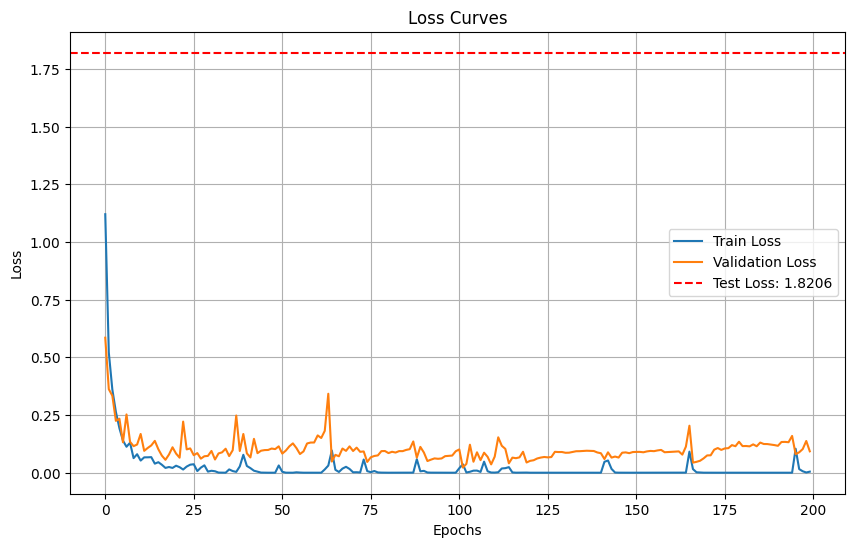

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_acc = model.evaluate(test_ds)
plt.axhline(test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.4f}')

plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# Print model summary
model.summary()

Model: "VGG_Five_Blocks_Classification_batchsize32"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling

1/1 [==============================] - 0s 245ms/step


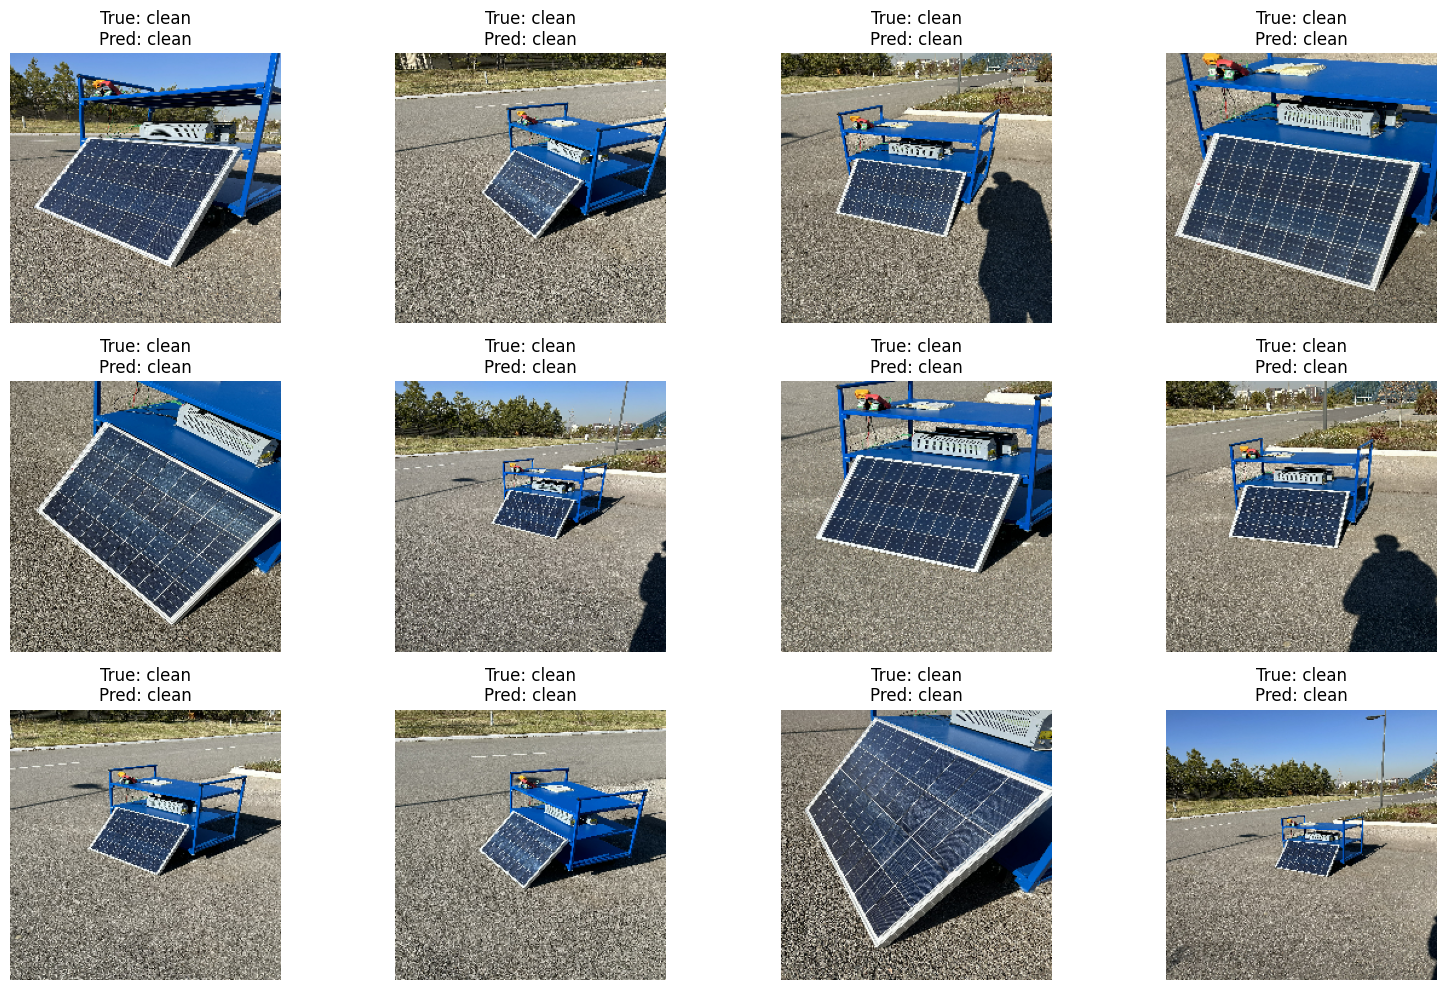

In [ ]:
# 11) OPTIONAL: EXAMPLE PREDICTIONS
def show_sample_predictions(test_ds, model, sample_count=12):
    class_names = ["clean", "dust", "snow", "water"]  # Update accordingly

    images = []
    labels = []
    preds = []

    count = 0
    for image_batch, label_batch in test_ds:
        batch_size = image_batch.shape[0]
        # Predict
        predictions = model.predict(image_batch)
        pred_classes = tf.argmax(predictions, axis=1)

        for i in range(batch_size):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            labels.append(label_batch[i].numpy())
            preds.append(pred_classes[i].numpy())
            count += 1
        
        if count >= sample_count:
            break

    # Plot
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")

    plt.tight_layout()
    plt.show()

# Show predictions for 12 images
show_sample_predictions(test_ds, model, sample_count=12)

In [17]:
# When creating your test dataset, shuffle it:
test_ds = df_to_dataset(test_data, shuffle=True, batch_size=32, augment=False)


1/1 [==============================] - 0s 25ms/step


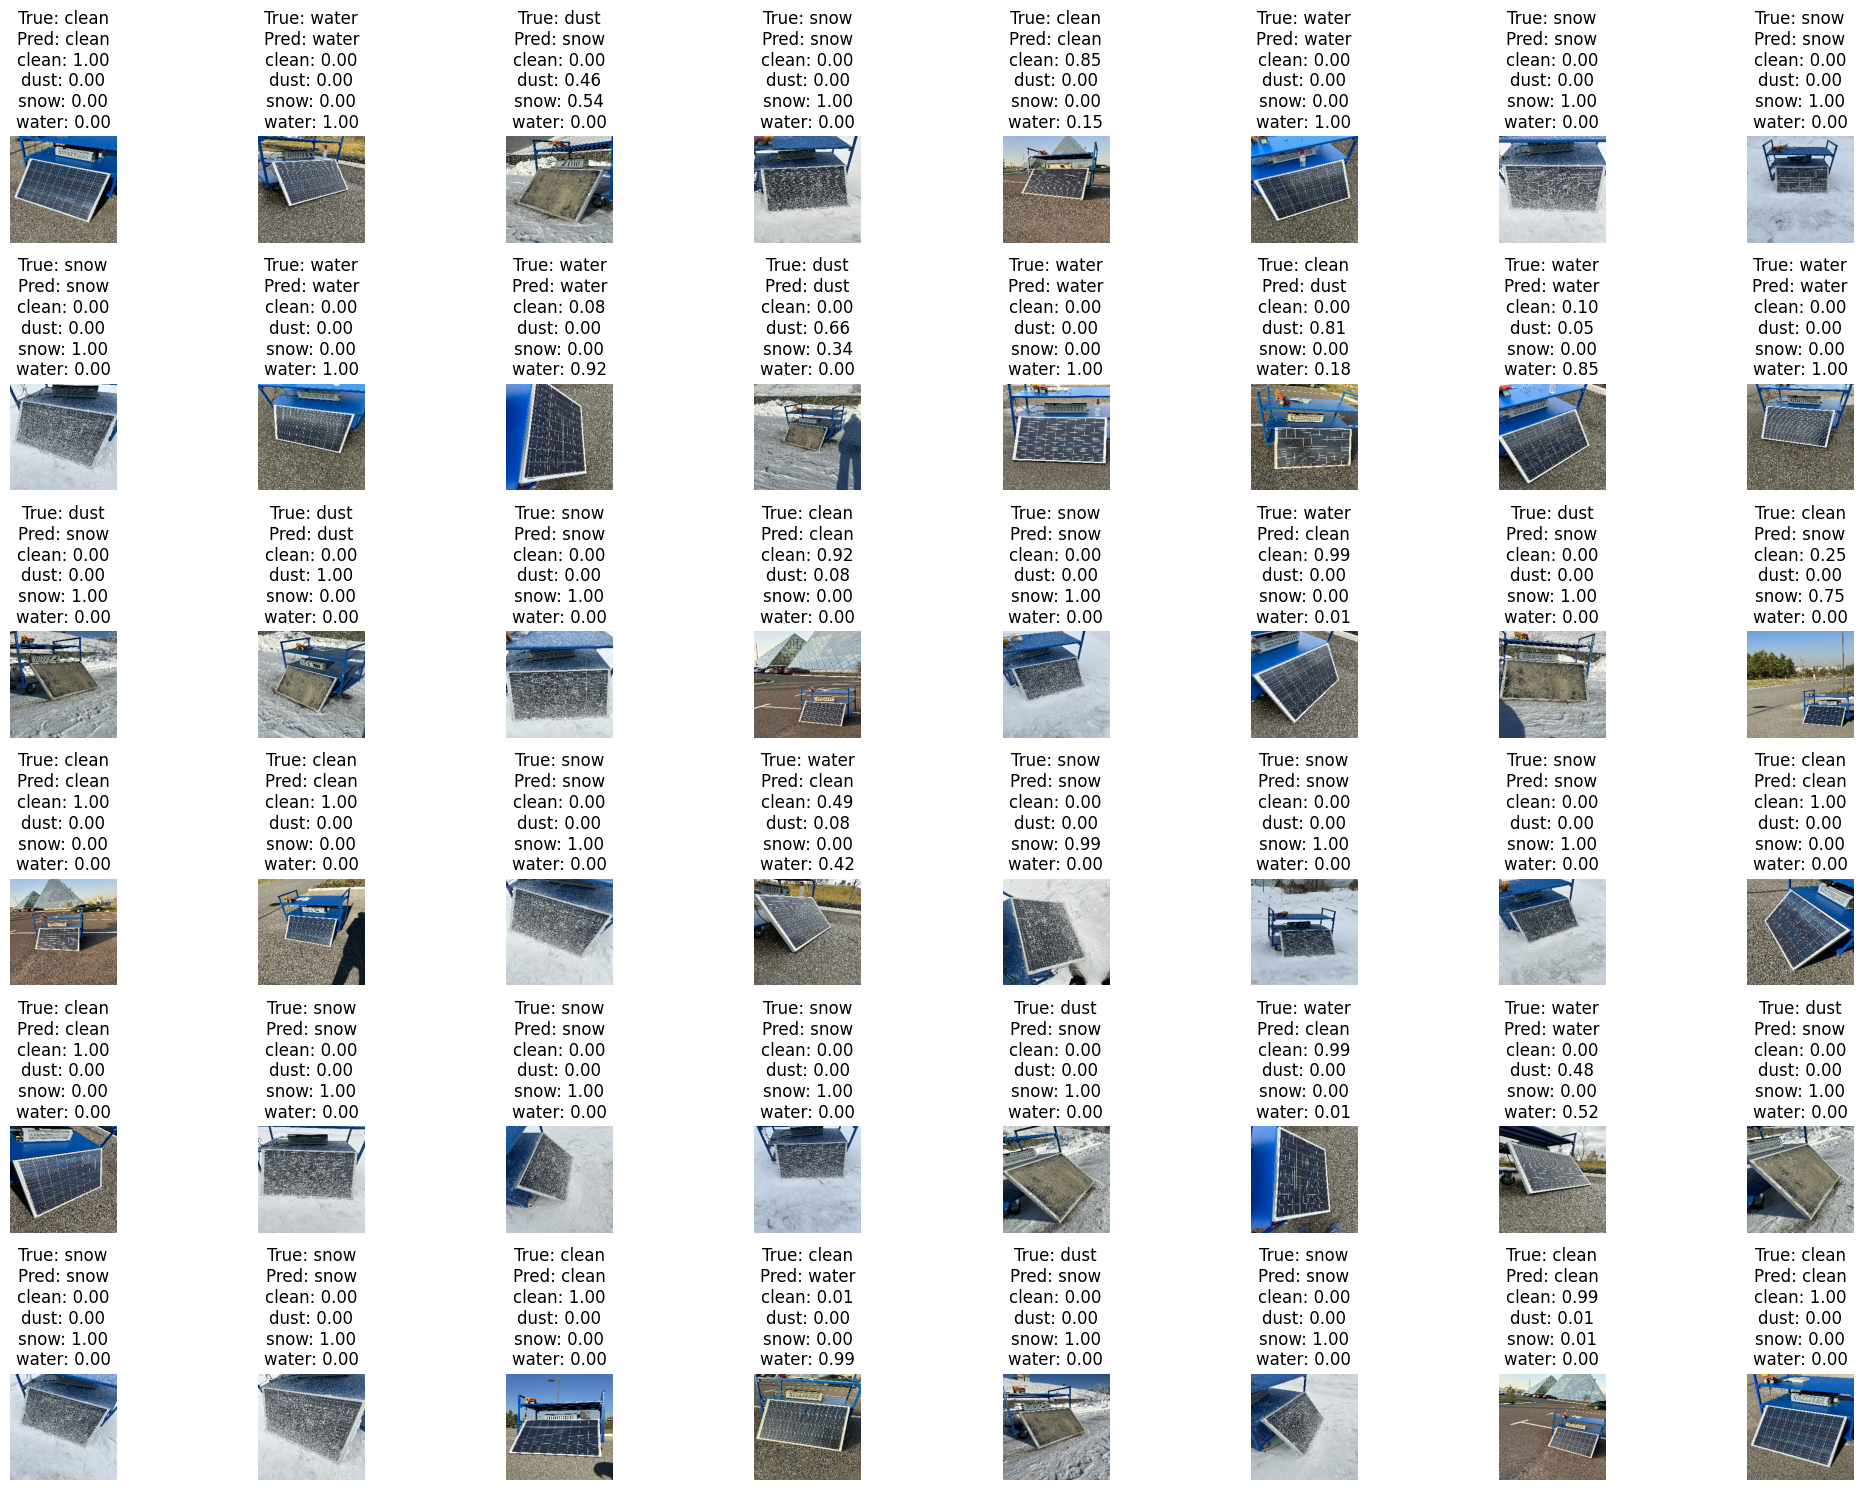

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def show_sample_predictions(test_ds, model, sample_count=48):
    # We'll display up to 'sample_count' images from test_ds
    class_names = ["clean", "dust", "snow", "water"]  # Update accordingly

    images = []
    labels = []
    preds = []
    pred_probs = []

    # We only need as many images as 'sample_count'
    count = 0
    # Shuffle the dataset before sampling images
    test_ds = test_ds.shuffle(buffer_size=1000)  # You can adjust buffer size based on the dataset size
    for image_batch, label_batch in test_ds:
        batch_size = image_batch.shape[0]
        # Predict
        predictions = model.predict(image_batch)
        
        for i in range(batch_size):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            labels.append(label_batch[i].numpy())
            pred_probs.append(predictions[i])  # Store all class probabilities for each image
            pred_classes = tf.argmax(predictions[i])  # Get the predicted class index
            preds.append(pred_classes.numpy())
            count += 1
        
        if count >= sample_count:
            break

    # Adjust the figure size to make the images larger
    fig, axes = plt.subplots(nrows=6, ncols=8, figsize=(20, 15))  # Increase figsize for larger images
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        # Get the probabilities for all classes
        prob_str = "\n".join([f"{class_names[i]}: {prob:.2f}" for i, prob in enumerate(pred_probs[idx])])
        ax.set_title(f"True: {true_label}\nPred: {pred_label}\n{prob_str}")

    plt.tight_layout()
    plt.show()

# Show predictions for 48 images
show_sample_predictions(test_ds, model, sample_count=48)
